In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
np.random.seed(42)

## Part 1: Problem framing and EDA

Here, I are working with the "Exam Score Prediction Dataset" which I have downloaded from Kaggle (link: https://www.kaggle.com/datasets/kundanbedmutha/exam-score-prediction-dataset/data). 

This dataset provides an extensive and realistic representation of various factors that contribute to student exam performance. This dataset includes 20000 records containing various informative columns each describing the study habits, student's academic behaviour, exam conditions and lifestyle routines. These collectively help us in understanding the different aspect of student's daily life and how learning environment can influence their exam outcomes.

This is a **Regression** problem, as I am going to predict the *Exam Scores* of students based on the columns describing their lifestyle, exam difficulty and behaviour.

Let's start with importing the dataset and them perform some basic EDA analysis on it

In [4]:
df = pd.read_csv(r'C:\Users\aryan\OneDrive\Desktop\InIT\Exam_Score_Prediction.csv')

print(df.shape)    # Provides (rows, columns) of the df (We have 20000 rows and 13 columns)

print('\n')
print(df.info())

print('\n')
print(df.describe())   # Gives the basic statistics such as mean, median, std along with other statistical information

print('\n')
print(df.isnull().sum())    # No null values in the dataset

(20000, 13)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB
None


         student_id           age   study_hours  class_attendance  \
count  20000.000000  20000.000000 

In [5]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

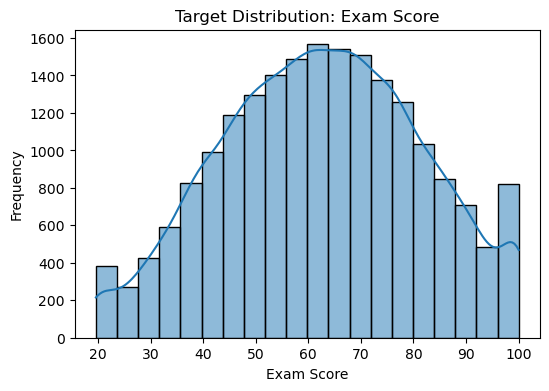

In [6]:
# Target Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['exam_score'], bins=20, kde=True)   # KDE gives a smooth representation of data's distribution
plt.title("Target Distribution: Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

From the above graph we can see that the Target Distribution is normal in nature (has approximately normal skew) but we can see that there are minor outliers at both the extremes (lowest scores and the highest scores).

The spread of scores tells us that it has moderate variability which implies differences in student performance but not a very severe imbalance.

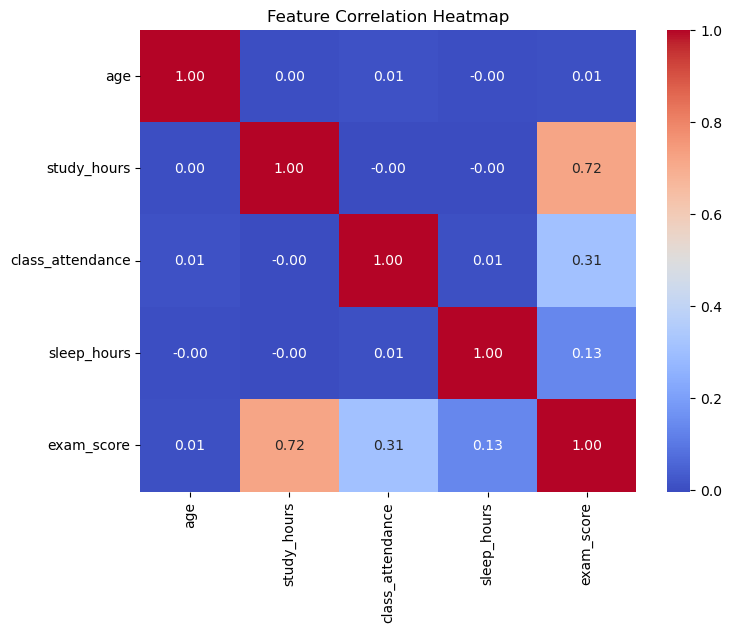

In [7]:
# Feature relationship

# Extracting important numerical columns for performing feature relationship
numeric_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']

plt.figure(figsize=(8,6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot= True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

From the above Heatmap, we understand:
1. **study_hours** and **class_attendance** show a positive correlation with the **exam_score**, indicating that increased study time and regular attendance are associated with better academic performance.
2. **sleep_hours** shows weak relationship, suggesting that sleep leads to little to no contribution in academic performance.
3. There are no extremely high correlations (i.e. > 0.9) among the features which means there is low multicollinearity.

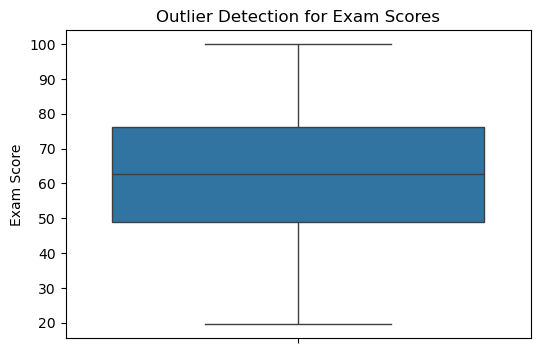

In [8]:
# Outlier check

plt.figure(figsize=(6,4))
sns.boxplot(y=df['exam_score'])
plt.title("Outlier Detection for Exam Scores")
plt.ylabel("Exam Score")
plt.show()

The boxplot of exam_score shows that most values like within a moderate interquartile range. The median score is also centrally located, suggesting that this is a balanced distribution

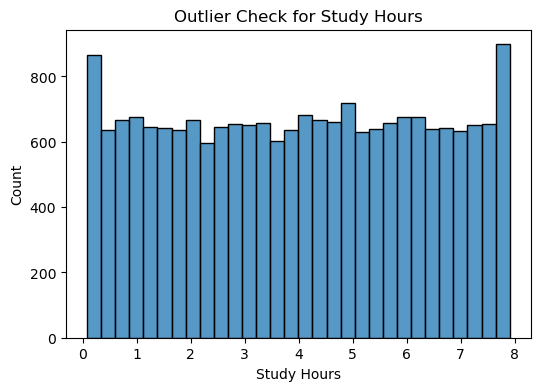

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['study_hours'], bins=30)
plt.title("Outlier Check for Study Hours")
plt.xlabel("Study Hours")
plt.show()

The histogram of study_hours shows a fairly uniform distributiion accross the observed range, indicating that students' time of studying is spread evenly. There are no visible extreme spikes which tells us that outliers are not present. The range of study hours alsp appeard to be realistic along with their count.

## Part 2: Preprocessing and data split

['study_hours', 'class_attendance', 'sleep_hours', 'exam_score']


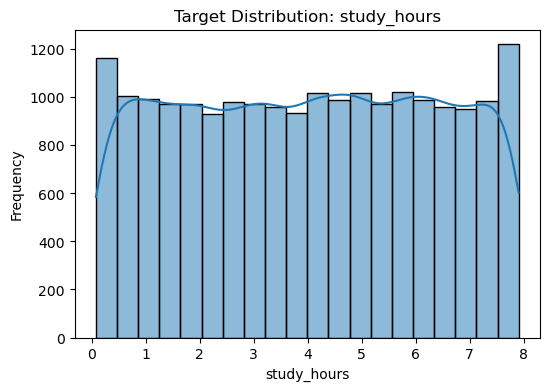

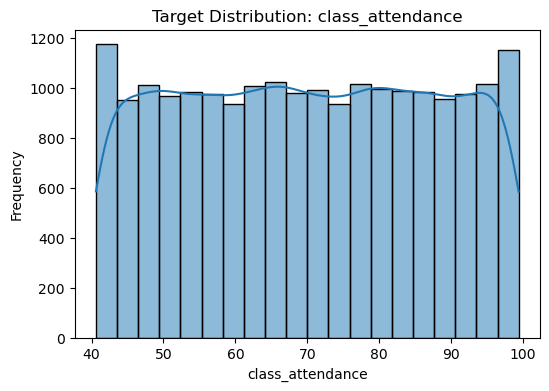

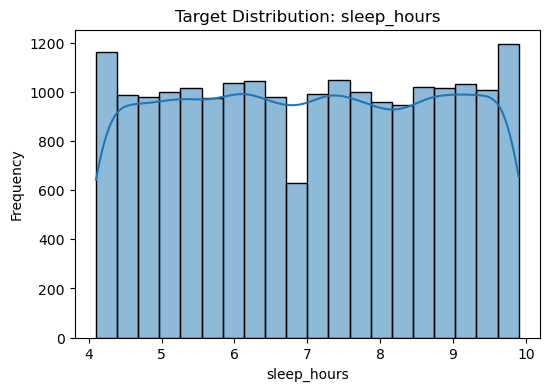

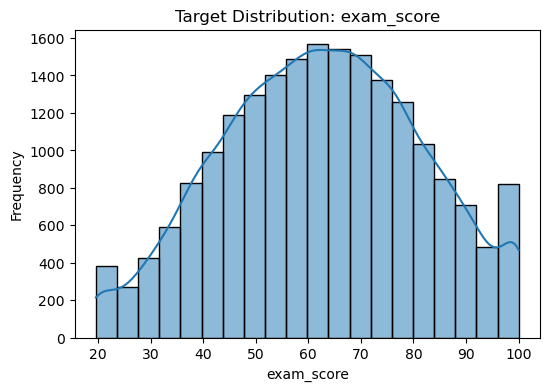

In [10]:
cols = [col for col in df.columns if df[col].dtype != 'object' and col not in ['student_id', 'age']]
print(cols)

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)   # KDE gives a smooth representation of data's distribution
    plt.title(f"Target Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

From the above distribution, we can understand that there are no data points which are skewed to a large extent or have long tails to affect the linear model's predictions, so I am just going to use StandardScaler to scale the features.

In [11]:
target = 'exam_score'

X = df[[col for col in df.columns if col!=target]]
y = df[target]

# Removing un-important columns
drop_cols = ['student_id', 'gender']
X.drop(drop_cols, axis=1, inplace= True)

C:\Users\aryan\AppData\Local\Temp\ipykernel_31696\2767657281.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(drop_cols, axis=1, inplace= True)


In [12]:
# We won't do missing value handling as our dataset already has no null values

# Creating a train_test_split function
def train_test_split(X, y, test_size=0.2, random_seed=None):

    n_samples = len(X)

    if random_seed is not None:
        np.random.seed(random_seed)
    
    indices = np.random.permutation(n_samples)

    test_count = int(n_samples*test_size)

    test_indices = indices[:test_count]
    train_indices = indices[test_count:]

    X_train = X.iloc[train_indices].reset_index(drop=True)
    X_test = X.iloc[test_indices].reset_index(drop=True)
    
    y_train = y.iloc[train_indices].reset_index(drop=True)
    y_test = y.iloc[test_indices].reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_seed=42)

In [14]:
cat_cols = ['course', 'study_method']
numeric_cols = [col for col in X.columns if X[col].dtype != 'object']
print(numeric_cols)

['age', 'study_hours', 'class_attendance', 'sleep_hours']


In [15]:
# Applying necessary OneHotEncoding and Ordinal Encoding

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

transformer = ColumnTransformer(transformers=[
        ('tnf1', OrdinalEncoder(categories=[['no', 'yes'], ['poor', 'average', 'good'], ['low', 'medium', 'high'], ['easy', 'moderate', 'hard']]), ['internet_access', 'sleep_quality', 'facility_rating', 'exam_difficulty']),
        ('tnf2', OneHotEncoder(sparse_output= False, handle_unknown='ignore'), cat_cols),
        ('tnf-num', StandardScaler(), numeric_cols)
    ], remainder='drop'
)

In [16]:
transformer.fit(X_train)

ColumnTransformer(transformers=[('tnf1',
                                 OrdinalEncoder(categories=[['no', 'yes'],
                                                            ['poor', 'average',
                                                             'good'],
                                                            ['low', 'medium',
                                                             'high'],
                                                            ['easy', 'moderate',
                                                             'hard']]),
                                 ['internet_access', 'sleep_quality',
                                  'facility_rating', 'exam_difficulty']),
                                ('tnf2',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['course', 'study_method']),
                                ('tnf-num', StandardScaler(),
                                 ['age', 'study_hours', 'class_attendance',
                                  'sleep_hours'])])

In [17]:
from knn import KNNRegression   # Stored in seperate file for less cluttering
from sklearn.pipeline import Pipeline

knn_reg = KNNRegression(n_neighbors=5, weights='distance')

# Creating a pipeline containing the column transformers and Scratch KNNRegressor
pipe = Pipeline([
    ('column_transformer', transformer),
    ('knn_regressor', knn_reg)
])

In [18]:
# Used for visualizing the pipeline

from sklearn import set_config
set_config(display='diagram')

In [19]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(transformers=[('tnf1',
                                                  OrdinalEncoder(categories=[['no',
                                                                              'yes'],
                                                                             ['poor',
                                                                              'average',
                                                                              'good'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high'],
                                                                             ['easy',
                                                                              'moderate',
                                                                              'hard']]),
                                                  ['internet_access',
                                                   'sleep_quality',
                                                   'facility_rating',
                                                   'exam_difficulty']),
                                                 ('tnf2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['course', 'study_method']),
                                                 ('tnf-num', StandardScaler(),
                                                  ['age', 'study_hours',
                                                   'class_attendance',
                                                   'sleep_hours'])])),
                ('knn_regressor',
                 <knn.KNNRegression object at 0x000002A7B5083B90>)])

In [20]:
y_pred = pipe.predict(X_test)

c:\Users\aryan\anaconda3\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [21]:
# Lets evaluate our model using self implemented evaluation metrics

from evaluation import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

MAE: 62.376409254835146
MSE: 4248.647856966164
R2 : -10.877783837419853


In [22]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg_base = KNeighborsRegressor(n_neighbors=5, weights='distance')

pipe2 = Pipeline([
    ('column_transformer', transformer),
    ('knn_regressor', knn_reg_base)
])

pipe2.fit(X_train, y_train)
y_pred_2 = pipe.predict(X_test)

c:\Users\aryan\anaconda3\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [23]:
# Lets evaluate the base sklearn model using self implemented evaluation metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_2))
print("MSE:", mean_squared_error(y_test, y_pred_2))
print("R2 :", r2_score(y_test, y_pred_2))

MAE: 62.3764092548353
MSE: 4248.647856966157
R2 : -10.877783837419779


The KNN regression model  performed poorly, with an MAE of 62.38 and an R² score of −10.88, indicating that the model performs significantly worse than a naive mean predictor. This suggests that the core assumption of KNN - that nearby points in feature space have similar target values does not hold well for this dataset. The model is highly sensitive to feature scaling and the choice of k, and errors were particularly large for test samples located in sparse regions of the feature space where nearest neighbors were not representative. These results highlight the limitations of distance-based methods in higher-dimensional data even if they are scaled.

## Part 4: Unsupervised learning and reflection

For unsupevised algorithm, I am working with a Ship Performamce database from Kaggle:
link (https://www.kaggle.com/datasets/jeleeladekunlefijabi/ship-performance-clustering-dataset/data)

which basically aims to understanding ship performance, fuel efficienct and operational cost factors which are essential for improving decision-making and minimizing environmental impact


Let us import the dataset and perform EDA on it.

In [24]:
df_2 = pd.read_csv(r'C:\Users\aryan\OneDrive\Desktop\InIT\Ship_Performance_Dataset.csv')

In [25]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2736 non-null   object 
 1   Ship_Type                2600 non-null   object 
 2   Route_Type               2600 non-null   object 
 3   Engine_Type              2600 non-null   object 
 4   Maintenance_Status       2600 non-null   object 
 5   Speed_Over_Ground_knots  2736 non-null   float64
 6   Engine_Power_kW          2736 non-null   float64
 7   Distance_Traveled_nm     2736 non-null   float64
 8   Draft_meters             2736 non-null   float64
 9   Weather_Condition        2600 non-null   object 
 10  Cargo_Weight_tons        2736 non-null   float64
 11  Operational_Cost_USD     2736 non-null   float64
 12  Revenue_per_Voyage_USD   2736 non-null   float64
 13  Turnaround_Time_hours    2736 non-null   float64
 14  Efficiency_nm_per_kWh   

In [26]:
df_2.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


In [27]:
df_2['Route_Type'].value_counts()

Route_Type
Long-haul       686
Coastal         650
Transoceanic    638
Short-haul      626
Name: count, dtype: int64

In [28]:
df_2.describe()

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
count,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000
mean,17.602863,1757.610939,1036.406203,9.929103,1032.573264,255143.344488,521362.062011,41.747536,0.798656,1.003816,4.914839,75.219222
std,4.311979,717.002777,568.632080,2.876423,558.697499,140890.482189,271211.625499,17.633130,0.403590,0.288251,2.597647,14.510168
min,10.009756,501.025220,50.433150,5.001947,50.229624,10092.306318,50351.814447,12.019909,0.100211,0.500004,1.000000,50.012005
25%,13.928452,1148.104914,548.511573,7.437485,553.983629,131293.378767,290346.388017,26.173537,0.463592,0.758033,3.000000,62.703724
50%,17.713757,1757.494344,1037.816060,9.918965,1043.207497,257157.653226,520176.931762,41.585188,0.789877,1.009009,5.000000,75.504709
75%,21.284785,2382.594292,1540.934161,12.413149,1527.722391,381796.930499,750072.791216,57.363922,1.147426,1.252808,7.000000,87.721205
max,24.997043,2998.734329,1998.337057,14.992947,1999.126697,499734.867868,999916.696140,71.972415,1.499259,1.499224,9.000000,99.999643


In [29]:
# Checking for null values

df_2.isnull().sum()

Date                         0
Ship_Type                  136
Route_Type                 136
Engine_Type                136
Maintenance_Status         136
Speed_Over_Ground_knots      0
Engine_Power_kW              0
Distance_Traveled_nm         0
Draft_meters                 0
Weather_Condition          136
Cargo_Weight_tons            0
Operational_Cost_USD         0
Revenue_per_Voyage_USD       0
Turnaround_Time_hours        0
Efficiency_nm_per_kWh        0
Seasonal_Impact_Score        0
Weekly_Voyage_Count          0
Average_Load_Percentage      0
dtype: int64

In [30]:
# Dropping the missing values as it seems the most suitable choice
df_2.dropna(inplace=True)

In [31]:
df_2['Date'] = pd.to_datetime(df_2['Date'])
df_2['Month'] = df_2['Date'].dt.month
df_2.drop(columns=['Date'], inplace=True)

In [32]:
numeric_cols = [cols for cols in df_2.columns if df_2[cols].dtype != 'object' and cols != 'Month']
numeric_cols

['Speed_Over_Ground_knots',
 'Engine_Power_kW',
 'Distance_Traveled_nm',
 'Draft_meters',
 'Cargo_Weight_tons',
 'Operational_Cost_USD',
 'Revenue_per_Voyage_USD',
 'Turnaround_Time_hours',
 'Efficiency_nm_per_kWh',
 'Seasonal_Impact_Score',
 'Weekly_Voyage_Count',
 'Average_Load_Percentage']

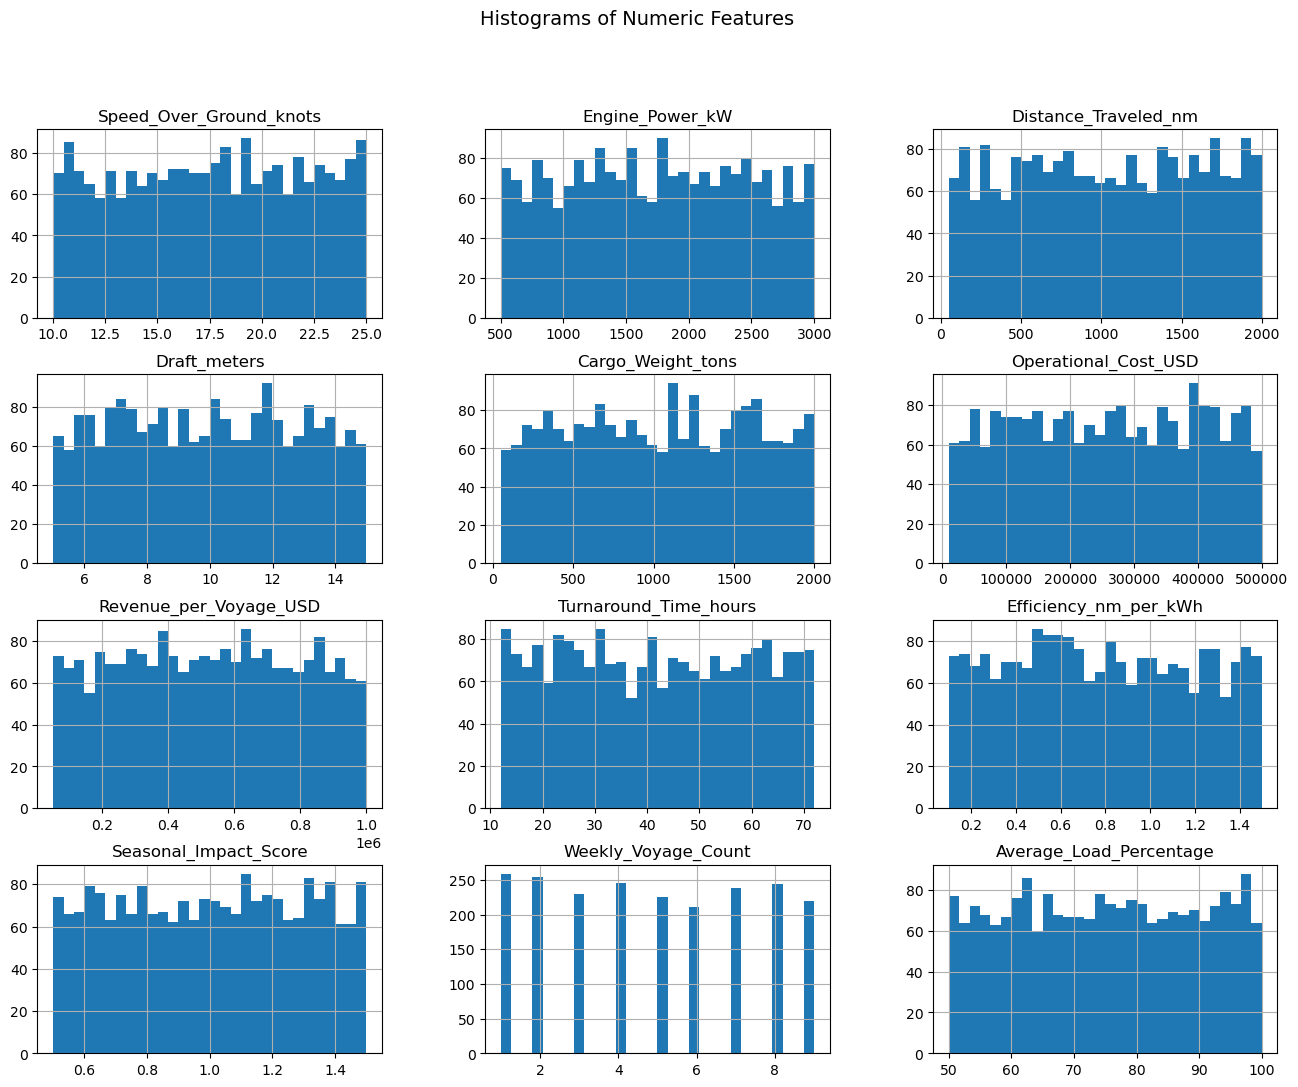

In [33]:
df_2[numeric_cols].hist(
    figsize=(16, 12),
    bins=30
)
plt.suptitle("Histograms of Numeric Features", fontsize=14)
plt.show()

We can see that normalization is required as most of the features are uniformly distributed over a wide range and with differenct scales across the variables. I am going to use StandardScaler for normalizing the above numeric columns

In [34]:
transformer_2 = ColumnTransformer([
    ('tnf1', OrdinalEncoder(categories=[['Critical', 'Fair', 'Good'], ['Rough', 'Moderate', 'Calm'], ['Short-haul', 'Coastal', 'Long-haul', 'Transoceanic']]), ['Maintenance_Status', 'Weather_Condition', 'Route_Type']),
    ('tnf2', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Ship_Type', 'Engine_Type']),
    ('tnf3', StandardScaler(), numeric_cols),
], remainder='drop')

We are going to sue K-means clustering algorithm for performing unsupervised learning, we are also going to use Principal Component Analysis (PCA) to get rid of extra dimensions in our data as it reduces the dimensions, reduces nosiy data and also helps in making the euclidean distances meaningful which is important for the working of KMeans 

In [35]:
from PCA import PCA
from k_means import KMeans

pipe_1 = Pipeline([
    ('column_transformer', transformer_2),
    ('PCA', PCA(n_components=2)),
    ('kmeans_clustering', KMeans(random_state=42, n_clusters=3))
])

In [36]:
pipe_1.fit(df_2)

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(transformers=[('tnf1',
                                                  OrdinalEncoder(categories=[['Critical',
                                                                              'Fair',
                                                                              'Good'],
                                                                             ['Rough',
                                                                              'Moderate',
                                                                              'Calm'],
                                                                             ['Short-haul',
                                                                              'Coastal',
                                                                              'Long-haul',
                                                                              'Transoceanic']]),
                                                  ['Maintenance_Status',
                                                   'Weather_Condition',
                                                   'Route_Type']),
                                                 ('tnf2',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Ship_Type'...
                                                   'Engine_Power_kW',
                                                   'Distance_Traveled_nm',
                                                   'Draft_meters',
                                                   'Cargo_Weight_tons',
                                                   'Operational_Cost_USD',
                                                   'Revenue_per_Voyage_USD',
                                                   'Turnaround_Time_hours',
                                                   'Efficiency_nm_per_kWh',
                                                   'Seasonal_Impact_Score',
                                                   'Weekly_Voyage_Count',
                                                   'Average_Load_Percentage'])])),
                ('PCA', <PCA.PCA object at 0x000002A7B6C3C830>),
                ('kmeans_clustering',
                 <k_means.KMeans object at 0x000002A7B6BB2BD0>)])

In [38]:
from sklearn.metrics import silhouette_score

kmeans_labels = pipe_1.named_steps['kmeans_clustering'].labels

print('Previous shape: ', df_2.shape)

df_transformed = pipe_1[:-1].transform(df_2)
print('Transformed Shape: ', df_transformed.shape)

kmeans_score = silhouette_score(df_transformed, kmeans_labels)
print('K-Means Score: ', kmeans_score)

Previous shape:  (2127, 18)
Transformed Shape:  (2127, 2)
K-Means Score:  0.3657572038050841


Let's plot how our unsupervised k-means has performed here

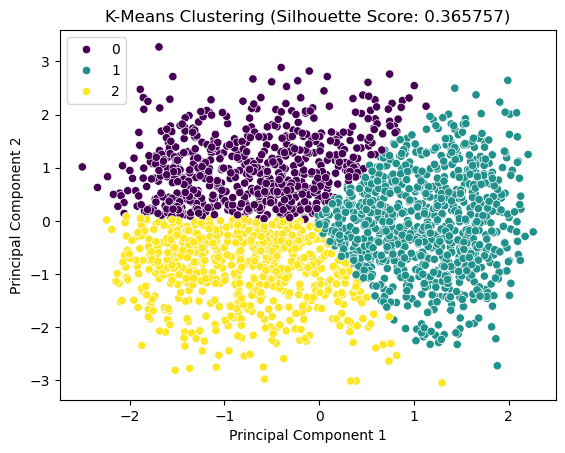

In [39]:
plt.Figure(figsize=(12,5))
sns.scatterplot(x=df_transformed[:,0], y=df_transformed[:, 1], hue=kmeans_labels, palette='viridis')
plt.title(f'K-Means Clustering (Silhouette Score: {kmeans_score:2f})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()